<a href="https://colab.research.google.com/github/DarshanSuresh/Fractional_Insider_Threat_Research/blob/main/Fractional_Insider_Threat_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fractional Order Explainable Insider Threat Detection Framework
Publication-oriented notebook with Behavioral Graph Analytics and Machine Learning

In [ ]:

# Install packages (run once)
# !pip install pandas numpy matplotlib seaborn scikit-learn networkx xgboost lightgbm shap faker


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


## Load Dataset

In [ ]:

df = pd.read_csv('/content/insider_threat.csv')
df.head()


,timestamp,src_ip,dst_ip,username,department,protocol,source_port,destination_port,packet_size,bytes_sent,...,email_sent_count,usb_inserted,database_queries,privilege_level,access_sensitive_data,off_hours_activity,geo_location,vpn_used,anomaly_score,insider_threat_label
0,2026-03-17 07:08:54.433311,10.101.238.14,10.215.20.63,user_97,IT,HTTPS,56433,80,1006,487787,...,22,0,142,User,0,1,Singapore,1,33.72,0
1,2026-03-28 23:26:03.454183,172.21.66.61,172.28.209.132,user_181,Finance,TCP,18790,80,277,352328,...,7,0,72,User,1,0,Singapore,0,81.09,0
2,2026-06-01 12:08:37.933655,172.30.194.60,172.24.67.82,user_391,Research,SMB,41742,3389,423,165460,...,15,0,76,PowerUser,0,0,Germany,1,52.47,0
3,2026-04-25 08:50:49.727146,172.20.111.16,10.158.171.110,user_68,IT,UDP,62603,80,1442,1479933,...,7,0,99,User,0,0,Germany,1,38.23,0
4,2026-04-05 07:50:19.564728,10.29.163.4,10.30.119.236,user_316,Research,HTTPS,15656,80,1389,934570,...,24,0,41,Admin,0,0,USA,1,29.44,0


## Exploratory Data Analysis

In [ ]:

print(df.shape)
print(df.info())
print(df.describe())


(5000, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   timestamp              5000 non-null   object 
 1   src_ip                 5000 non-null   object 
 2   dst_ip                 5000 non-null   object 
 3   username               5000 non-null   object 
 4   department             5000 non-null   object 
 5   protocol               5000 non-null   object 
 6   source_port            5000 non-null   int64  
 7   destination_port       5000 non-null   int64  
 8   packet_size            5000 non-null   int64  
 9   bytes_sent             5000 non-null   int64  
 10  bytes_received         5000 non-null   int64  
 11  session_duration       5000 non-null   int64  
 12  login_time             5000 non-null   object 
 13  logout_time            5000 non-null   object 
 14  login_success          5000 non-null   int64 

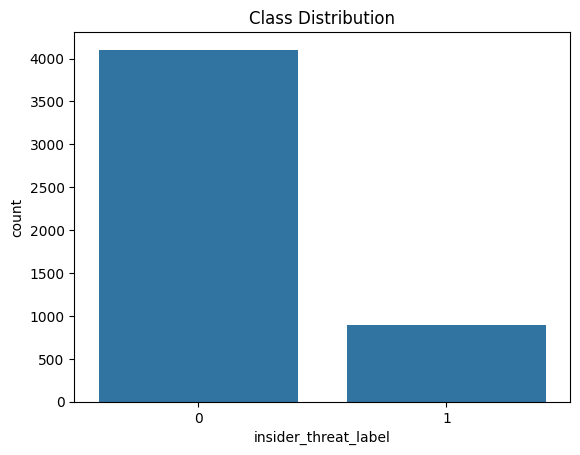

In [ ]:

sns.countplot(x='insider_threat_label', data=df)
plt.title('Class Distribution')
plt.show()


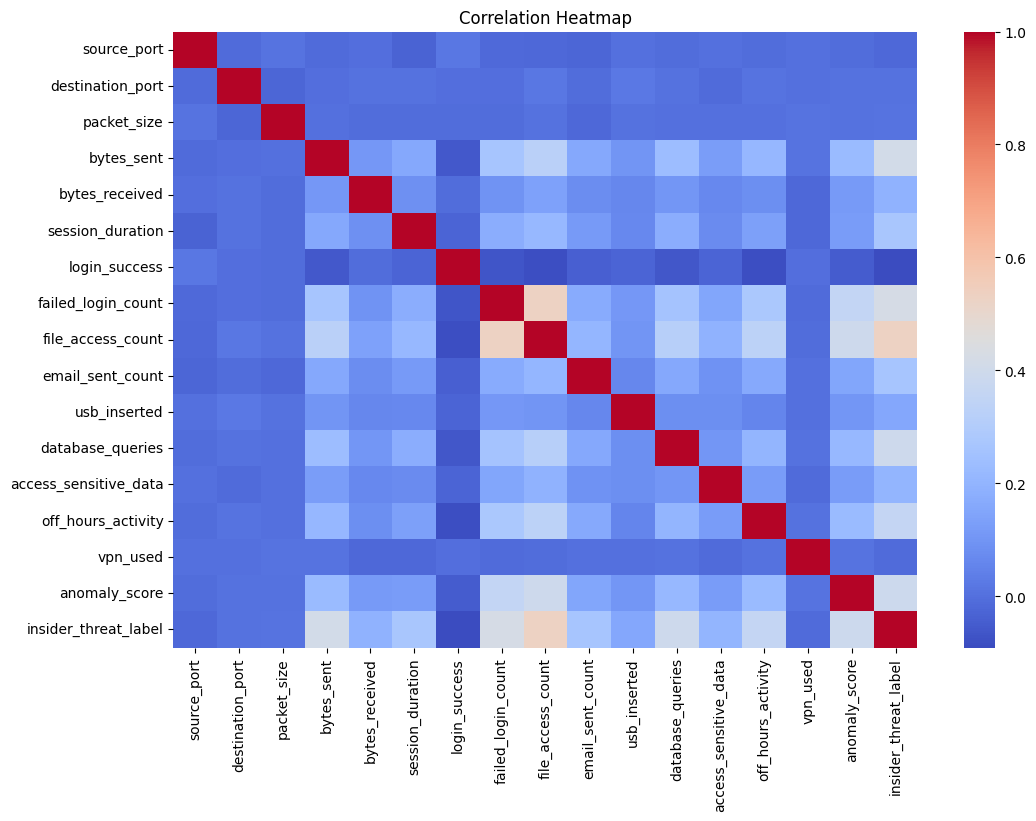

In [ ]:

numeric = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(numeric.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## Behavioral Graph Analytics

In [ ]:

G = nx.Graph()

for _, row in df.iterrows():
    user = row['username']
    resource = row['dst_ip']
    G.add_edge(user, resource)

print('Nodes:', len(G.nodes()))
print('Edges:', len(G.edges()))


Nodes: 5575
Edges: 5000


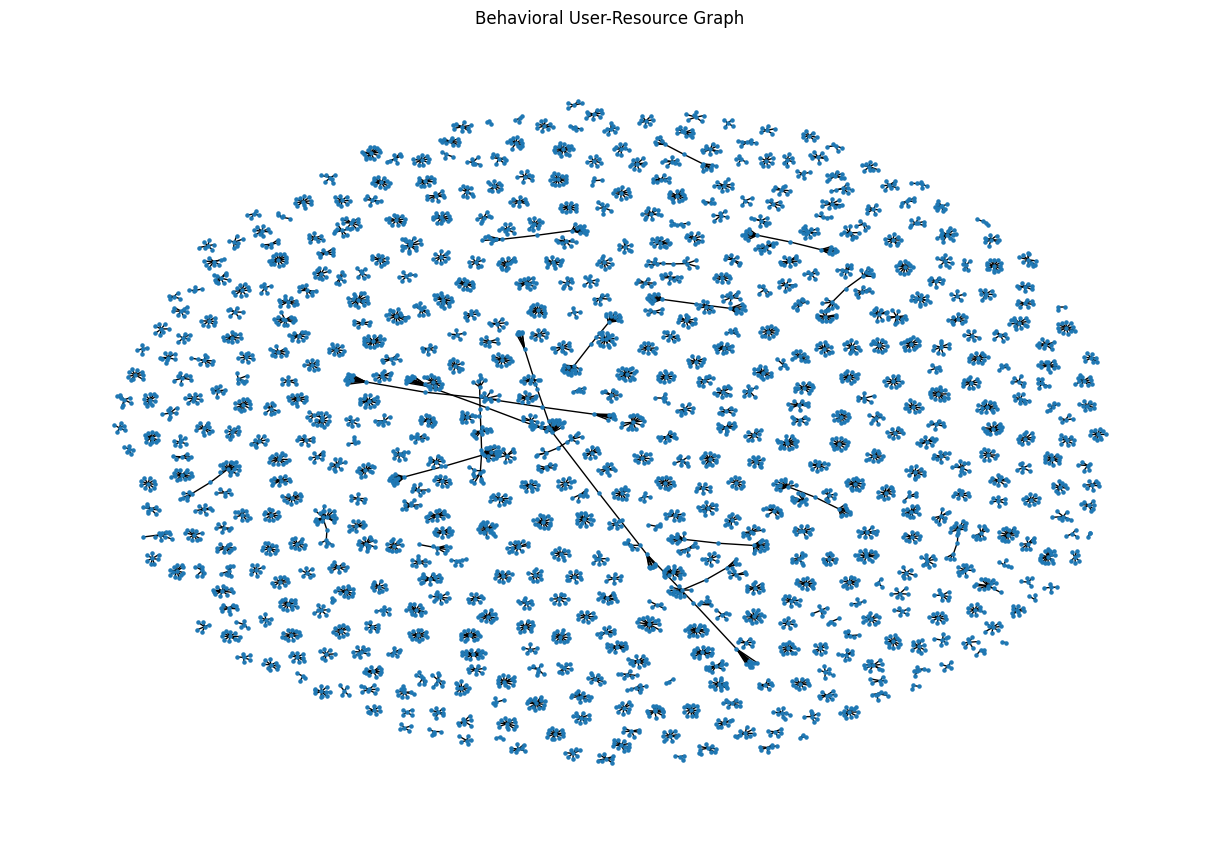

In [ ]:

plt.figure(figsize=(12,8))
nx.draw(G, node_size=5)
plt.title('Behavioral User-Resource Graph')
plt.show()


In [ ]:

degree = nx.degree_centrality(G)
pagerank = nx.pagerank(G)

df['degree_centrality'] = df['username'].map(degree)
df['pagerank'] = df['username'].map(pagerank)


## Fractional Risk Score

In [ ]:

alpha = 0.7

df['fractional_risk'] = (
    alpha * df['anomaly_score']
    + (1-alpha) * df['failed_login_count']
)


## Feature Engineering

In [ ]:

features = [
'packet_size',
'bytes_sent',
'bytes_received',
'session_duration',
'failed_login_count',
'file_access_count',
'email_sent_count',
'usb_inserted',
'database_queries',
'access_sensitive_data',
'off_hours_activity',
'anomaly_score',
'degree_centrality',
'pagerank',
'fractional_risk'
]

X = df[features]
y = df['insider_threat_label']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)


## Machine Learning Models

In [ ]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=300),
    'XGBoost': XGBClassifier(eval_metric='logloss'),
    'LightGBM': LGBMClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test,pred),
        'Precision': precision_score(y_test,pred),
        'Recall': recall_score(y_test,pred),
        'F1': f1_score(y_test,pred)
    })

results_df = pd.DataFrame(results)
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 716, number of negative: 3284
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2149
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.179000 -> initscore=-1.523137
[LightGBM] [Info] Start training from score -1.523137


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.846,0.610619,0.385475,0.472603
1,Random Forest,0.925,0.912698,0.642458,0.754098
2,XGBoost,0.921,0.862319,0.664804,0.750789
3,LightGBM,0.923,0.875000,0.664804,0.755556


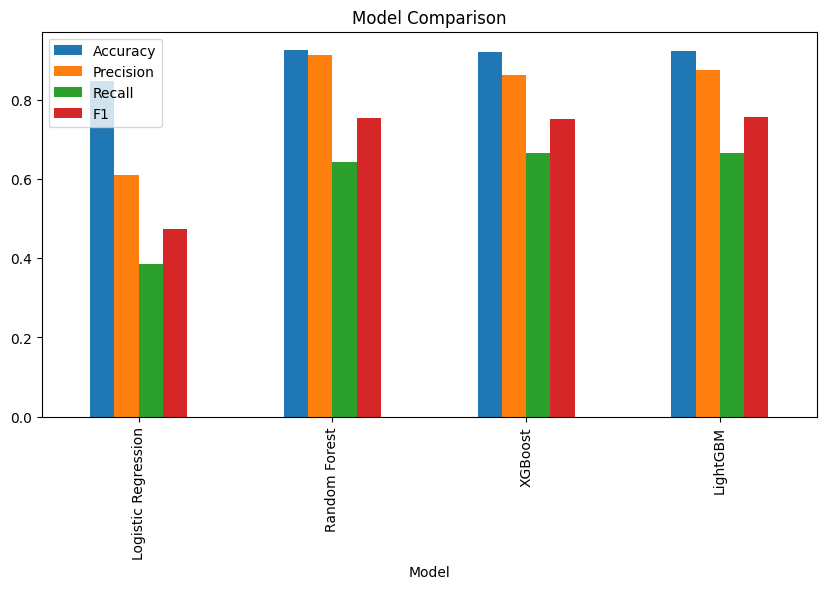

In [ ]:

results_df.plot(
x='Model',
y=['Accuracy','Precision','Recall','F1'],
kind='bar',
figsize=(10,5)
)
plt.title('Model Comparison')
plt.show()


## Confusion Matrix

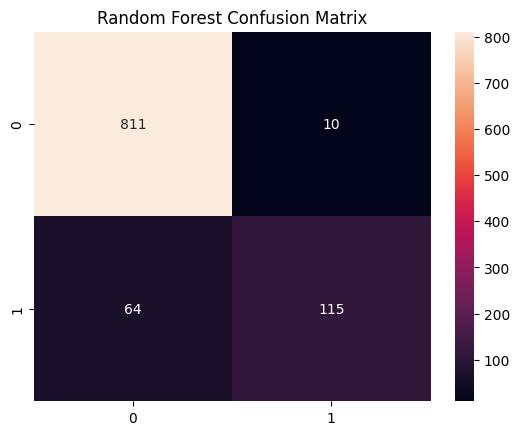

In [ ]:

rf = RandomForestClassifier(n_estimators=300)
rf.fit(X_train,y_train)

pred = rf.predict(X_test)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.show()


## Feature Importance

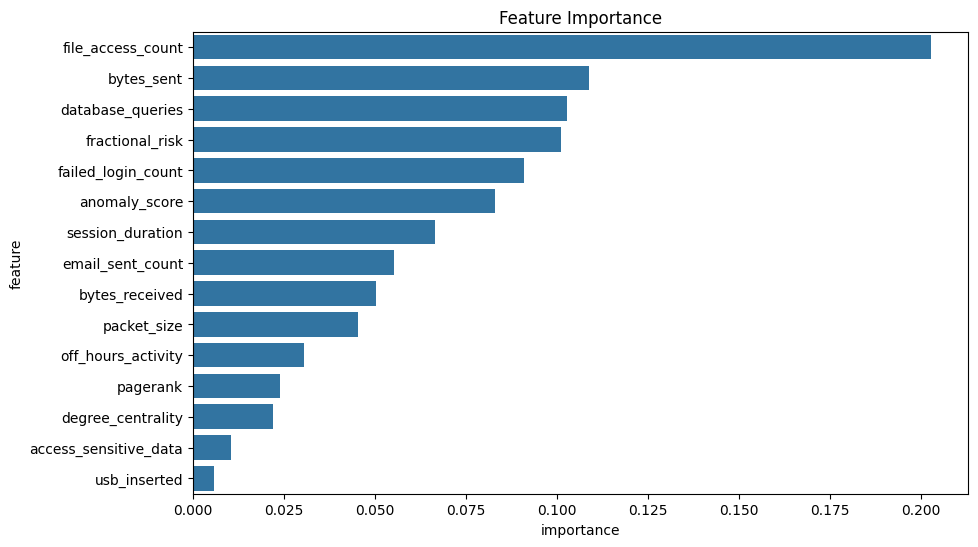

In [ ]:

imp = pd.DataFrame({
'feature':features,
'importance':rf.feature_importances_
}).sort_values('importance',ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp,x='importance',y='feature')
plt.title('Feature Importance')
plt.show()


## Community Detection

In [ ]:

from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))

print('Communities Found:', len(communities))


Communities Found: 575


## SHAP Explainability

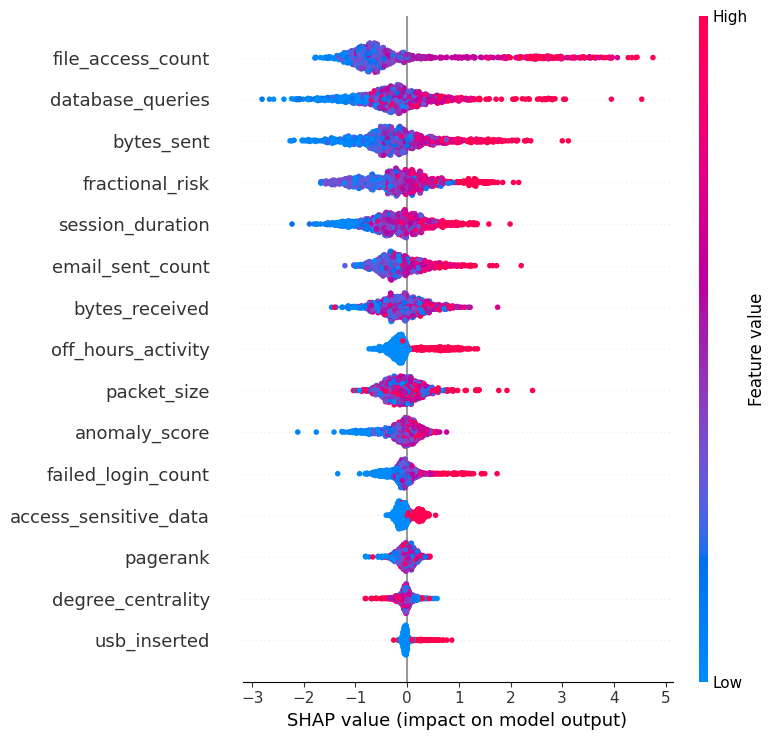

In [ ]:

import shap

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train,y_train)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)



# Publication Outputs

- Dataset Statistics
- Correlation Analysis
- Behavioral Graph Visualization
- Degree Centrality Features
- PageRank Features
- Fractional Risk Model
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM
- Model Comparison
- Confusion Matrix
- Feature Importance
- Community Detection
- SHAP Explainability


# Notebook 01: Dataset Engineering & Preprocessing